In [1]:
# import os
# import sys
# from pathlib import Path
# import shutil
# import datetime
# import math

# import attrs
# from liblaf import cherries
# from loguru import logger
# from tqdm import tqdm

# # 替换此行
# # sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname(__file__), "../../src")))

# # 方法1：使用当前工作目录
# notebook_dir = os.getcwd()  # 获取当前工作目录
# src_path = os.path.abspath(os.path.join(notebook_dir, "../../src"))
# sys.path.insert(0, src_path)


# import qoc
# import qoc.api as api # pyright: ignore


# db: str = qoc.data_dir("database").as_uri().replace("file://", "lmdb://")


# online: bool = False

# symbols: list[str] = [
#     "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
#     "LINKUSDT", "TRXUSDT", "DOTUSDT", "MATICUSDT", "LTCUSDT", "UNIUSDT", "ATOMUSDT", "ETCUSDT",
#     "ICPUSDT", "APTUSDT", "FILUSDT", "NEARUSDT", "HBARUSDT", "INJUSDT", "OPUSDT", "ARBUSDT",
#     "SUIUSDT", "SEIUSDT", "RENDERUSDT", "TIAUSDT", "FTMUSDT", "EGLDUSDT", "AAVEUSDT", "GALAUSDT",
#     "IMXUSDT", "PEPEUSDT", "SHIBUSDT", "FLOKIUSDT", "BONKUSDT", "WIFUSDT", "PENGUUSDT", "TRUMPUSDT",
#     "POLUSDT", "ENSUSDT", "JUPUSDT", "PYTHUSDT", "ORDIUSDT", "SATOSHIUSDT", "SATSUSDT", "MOVRUSDT",
#     "DYMUSDT", "NOTUSDT", "MAGAUSDT", "SPXUSDT"
# ]



# # symbols: list[str] = ["BTCUSDT", "DOGEUSDT"]
# transaction_fee: float = 0.01  # 交易费用为0.1%
# interval: str = "1m"
# start_date: str = "2024-09-01"
# end_date: str = "2025-08-31"
# output_dir: str = "mmpair-strategy/1m_klines_raw"


# offline_db_path = Path("mmpair-strategy")
# if offline_db_path.exists():
#     # logger.info(f"删除现有数据库文件夹: {offline_db_path}")
#     shutil.rmtree(offline_db_path)


# from offline_fetch import fetch_for_offline
# import arcticdb as adb
# uri = "lmdb://mmpair-strategy"

# ac = adb.Arctic(uri)

# qoc_library = ac.get_library('market', create_if_missing=True)

# fetch_for_offline(symbols, interval, start_date, end_date, output_dir, qoc_library)


In [2]:
from pathlib import Path
import copy
import pandas as pd

output_dir = "mmpair-strategy/1m_klines_raw"
output_path = Path(output_dir)

coins_dict = {}
    
for file in output_path.iterdir():
    if file.is_file() and file.suffix.lower() == ".csv":
        df = pd.read_csv(file, encoding="utf-8")

        df["Close Time"] = df["Close Time"].apply(
            lambda x: x * 1000 + 999 if x < 2000000000000 else x
        )

        df["Close Time"] = pd.to_datetime(df["Close Time"], unit="us")

        df.columns = df.columns.str.strip().str.replace("\ufeff", "", regex=False)

        if "Close" not in df.columns or "Close Time" not in df.columns:
            print(f"⚠️ 跳过无 Close 或 Close Time 的文件: {file.name}")
            continue

        df.set_index("Close Time", inplace=True)
        symbol = file.stem.split("_")[0]
        
        if len(df) ==525600:
            coins_dict[symbol] = df
            print(f"Processing symbol: {symbol}, length: {len(df)}")


btc = coins_dict["BTCUSDT"]
chosen = [ 
    "BTCUSDT", "ETHUSDT", "BNBUSDT", "SOLUSDT", "XRPUSDT", "ADAUSDT", "DOGEUSDT", "AVAXUSDT",
    "LINKUSDT", "TRXUSDT"
    ]
HEDGE_LIST = {k: v for k, v in coins_dict.items() if k in chosen}


temp = copy.deepcopy(HEDGE_LIST)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Processing symbol: IMXUSDT, length: 525600
Processing symbol: SOLUSDT, length: 525600
Processing symbol: NOTUSDT, length: 525600
Processing symbol: BONKUSDT, length: 525600
Processing symbol: LTCUSDT, length: 525600
Processing symbol: ORDIUSDT, length: 525600
Processing symbol: SUIUSDT, length: 525600
Processing symbol: JUPUSDT, length: 525600
Processing symbol: NEARUSDT, length: 525600
Processing symbol: ATOMUSDT, length: 525600
Processing symbol: APTUSDT, length: 525600
Processing symbol: GALAUSDT, length: 525600
Processing symbol: ARBUSDT, length: 525600
Processing symbol: TRXUSDT, length: 525600
Processing symbol: BNBUSDT, length: 525600
Processing symbol: DOTUSDT, length: 525600
Processing symbol: FILUSDT, length: 525600
Processing symbol: ETCUSDT, length: 525600
Processing symbol: RENDERUSDT, length: 525600
Processing symbol: FLOKIUSDT, length: 525600
Processing symbol: BTCUSDT, length: 525600
Processing symbol: LINKUSDT, length: 525600
Processing symbol: SHIBUSDT, length: 525600

In [3]:
HEDGE_LIST = temp

In [4]:

import numpy as np
from scipy.optimize import linprog
import matplotlib.pyplot as plt
from collections import deque
from sklearn.linear_model import LinearRegression
from tqdm import tqdm
import random

In [5]:
len(HEDGE_LIST.keys())

10

In [6]:

# 截取前半段（会真正修改 HEDGE_LIST 中的每个 DataFrame）
half_length = 525600//1

i=1

for name, df in HEDGE_LIST.items():
    HEDGE_LIST[name] = df.iloc[(i-1)*half_length:i*half_length]    
    
btc = btc.iloc[(i-1)*half_length:i*half_length]    




In [18]:

BULLET_SIZE = 1000
INITIAL = 10000



FORWARD_WINDOW = 100
BACK_WINDOW = 200



MIN_POR = 0.05


In [19]:
back_window = BACK_WINDOW
forward_window = FORWARD_WINDOW
bullet_size = BULLET_SIZE


btc_close = deque(btc['Close'][:back_window], maxlen=back_window)
coin_closes = {name: deque(df['Close'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

btc_volume = deque(btc['Volume'][:back_window], maxlen=back_window)
coin_volumes = {name: deque(df['Volume'][:back_window], maxlen=back_window) for name, df in HEDGE_LIST.items()}

mkt_idx_1 = deque(np.array([0]*back_window), maxlen=back_window)
mkt_idx_2 = deque(np.array([0]*back_window), maxlen=back_window)

mi_1_fz = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
mi_1_fm = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
mi_2_fz = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
mi_2_fm = {name: deque(np.array([0]*back_window), maxlen=back_window) for name in HEDGE_LIST.keys()}
mi_1_fz_sum = {name: 0 for name in HEDGE_LIST.keys()}
mi_1_fm_sum = {name: 0 for name in HEDGE_LIST.keys()}
mi_2_fz_sum = {name: 0 for name in HEDGE_LIST.keys()}
mi_2_fm_sum = {name: 0 for name in HEDGE_LIST.keys()}


cmi_dict = {}


time_range = range(back_window, len(btc) - forward_window)

num = 0
revenues = []
stats_1 = []



sum_of_theta_price = 0

print_df = None

for i, t in tqdm(enumerate(time_range), total=len(time_range), desc="Sliding window"):

 

    btc_close.append(btc['Close'].iloc[t])
    btc_volume.append(btc['Volume'].iloc[t])

    arr = np.array(btc_close)

    diff = np.diff(arr)
    cmi_btc = (arr[-1] - arr[0]) / np.sum(np.abs(diff))*100

    fz = 0
    fm = 0

    coef_records = {name: [] for name in HEDGE_LIST.keys()}

    for name, df in HEDGE_LIST.items():
        coin_closes[name].append(df['Close'].iloc[t])
        coin_volumes[name].append(df['Volume'].iloc[t])

        if i>=back_window:

            growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) / np.array(coin_closes[name])[-2]
            fz += growth*df['Volume'].iloc[t]
            fm += df['Volume'].iloc[t]

    if i>=back_window:
        mkt_idx_1.append(btc['Close'].iloc[t])
        mkt_idx_2.append(fz/fm)


        mkt_idx_1_diff = mkt_idx_1[-1]-mkt_idx_1[-2]
        mkt_idx_2_diff = mkt_idx_2[-1]


        for name, _ in HEDGE_LIST.items():

            diff = np.diff(np.array(coin_closes[name]))
            cmi = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[0]) / np.sum(np.abs(diff))*100

            growth = (np.array(coin_closes[name])[-1] - np.array(coin_closes[name])[-2]) 

            if len(mi_1_fz[name])>=back_window:
                mi_1_fz_sum[name] -= mi_1_fz[name][0]
                mi_1_fm_sum[name] -= mi_1_fm[name][0]
                mi_2_fz_sum[name] -= mi_2_fz[name][0]
                mi_2_fm_sum[name] -= mi_2_fm[name][0]

            mi_1_fz[name].append(growth*mkt_idx_1_diff)
            mi_1_fm[name].append(mkt_idx_1_diff**2)
            mi_2_fz[name].append(growth*mkt_idx_2_diff)
            mi_2_fm[name].append(mkt_idx_2_diff**2)

            mi_1_fz_sum[name] += mi_1_fz[name][-1]
            mi_1_fm_sum[name] += mi_1_fm[name][-1]
            mi_2_fz_sum[name] += mi_2_fz[name][-1]
            mi_2_fm_sum[name] += mi_2_fm[name][-1]

            if i >= 2*back_window:
                coef_1 = mi_1_fz_sum[name]/mi_1_fm_sum[name]*1000 if mi_1_fm_sum[name]!=0 else 0
                coef_2 = mi_2_fz_sum[name]/mi_2_fm_sum[name]*1000 if mi_2_fm_sum[name]!=0 else 0 

                # RETURN
                coef_records[name] = {
                    'coef_1': coef_1,
                    'coef_2': coef_2,                
                    'cmi': cmi
                }

        if i >= 2*back_window:

            if i % forward_window == 0:
                # print(f"\n=== Step {i}: Coefficients collected for all coins ===")
                # === 将 coef_records 转为 DataFrame ===
                coef_df = pd.DataFrame.from_dict(coef_records, orient='index')  # index=coin

                coef_df['cmi'] = coef_df['cmi'].astype(float)
                coef_df['coef_1'] = coef_df['coef_1']
                coef_df['coef_2'] = coef_df['coef_2']

                names = coef_df.index.tolist()
                coef1 = coef_df['coef_1'].values.astype(float)
                coef2 = coef_df['coef_2'].values.astype(float)
                prices = coef_df.index.map(lambda n: HEDGE_LIST[n]['Close'].iloc[t]).values.astype(float)


                k = len(prices)

                cmis = coef_df['cmi'].values.astype(float)


                # 原目标函数 c^T x
                c_x = -cmis *prices

                # 我们引入新的变量 y_i 表示 |x_i * prices_i|
                # 所以变量总数 = k (x_i) + k (y_i)
                c = np.concatenate([c_x, np.zeros(k)])  # 目标函数只作用在 x 上

                # 线性约束 A_eq x = b_eq
                A_eq = np.hstack([np.vstack([coef1, coef2]), np.zeros((2, k))])
                b_eq = np.zeros(2)

                # --- 绝对值约束部分 ---
                # 对于每个 i: y_i >=  prices_i * x_i
                #             y_i >= -prices_i * x_i
                #             sum(y_i) <= 1000
                A_ub = []
                b_ub = []

                for i in range(k):
                    row_pos = np.zeros(2 * k)
                    row_pos[i] = prices[i]
                    row_pos[k + i] = -1
                    A_ub.append(row_pos)
                    b_ub.append(0.0)

                    row_neg = np.zeros(2 * k)
                    row_neg[i] = -prices[i]
                    row_neg[k + i] = -1
                    A_ub.append(row_neg)
                    b_ub.append(0.0)

                # sum(y_i) <= 1000
                row_sum = np.zeros(2 * k)
                row_sum[k:] = 1.0
                A_ub.append(row_sum)
                b_ub.append(1000.0)

                A_ub = np.array(A_ub)
                b_ub = np.array(b_ub)

                # 变量边界
                bounds = [(-np.inf, np.inf)] * k + [(0, np.inf)] * k
                # print(len(c))
                # print("shape of A_ub:", A_ub.shape)
                # print("shape of b_ub:", b_ub.shape)

                # 求解线性规划
                res = linprog(c=c, A_eq=A_eq, b_eq=b_eq, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method='highs')

                objective_value = res.fun  

                if res.success and objective_value < -7500:
                    theta = res.x[:k] 
                    
                    df = pd.DataFrame({
                        'name': names,
                        'coef_1': coef1,
                        'coef_2': coef2,
                        'price': prices,
                        'cmi': coef_df['cmi'].values,
                        'theta': theta,
                        'theta*price': theta * prices,
                        'theta*cmi': theta * coef_df['cmi'].values * prices,
                    })

                    print_df = df


                    sum_of_theta_price += sum(abs(theta * prices))


                    # if objective_value < -0: and min(df['correlation'])>0.6 and sharpe<0.5 and sharpe>-0.5:

                    num+=1    
                    stats_1.append(objective_value)


                    stop_loss_ratio = 0.02  # 2% 止损比例
                    revenue_path = np.zeros(forward_window)
                    revenue = 0.0

                    # === 构建逐步revenue序列 ===
                    for idx, row in df.iterrows():
                        name = row['name']
                        theta_value = row['theta']
                        price = HEDGE_LIST[name]['Close'].iloc[t]

                        # 对应币种未来价格路径
                        future_prices = HEDGE_LIST[name]['Close'].iloc[t:t + forward_window]
                        # 单币种逐步收益
                        future_revenues = (future_prices - price) * theta_value
                        # 累加到组合
                        revenue_path += future_revenues.values  # 确保是numpy array

                    # === 遍历止损逻辑 ===
                    stopped_revenue = revenue_path[-1]  # 默认没止损时最后一个
                    for r in revenue_path:
                        if abs(r) > 1000 * stop_loss_ratio:
                            stopped_revenue = r
                            break  # 触发止损
                    # for r in revenue_path:
                    #     if r < -100 * stop_loss_ratio or r > 100 * stop_loss_ratio:
                    #         stopped_revenue = r
                    #         break  # 触发止损
                    else:
                        stopped_revenue = revenue_path[-1]  # 没触发止损

                    revenues.append(stopped_revenue)
            if (i-1)%(forward_window*100)==0:
                # print(print_df)

                import numpy as np
                import pandas as pd
                import matplotlib.pyplot as plt

                # 假设 revenue_series 是 pandas Series 或 numpy array
                # 示例：
                revenue_series = pd.Series(revenues)

                # 1️⃣ 累积收益
                cumulative_revenue = np.cumsum(revenue_series)

                # 2️⃣ 绘图
                plt.figure(figsize=(10, 5))
                plt.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
                plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight='bold')
                plt.xlabel("Time Index")
                plt.ylabel("Cumulative Revenue")
                plt.grid(alpha=0.3)
                plt.legend()
                plt.tight_layout()
                plt.savefig("cumulative_revenue.png", dpi=300)
                plt.close()

                if sum_of_theta_price!=0:
                    print(f"🟢 Step {i}, cumulative {sum(revenues):.2f}, average {sum(revenues)/sum_of_theta_price:.8f}")
                # else:
                #     print("⚠️ 线性规划求解失败:", res.message)






Sliding window:   2%|▏         | 10264/525300 [00:06<08:02, 1068.17it/s]

🟢 Step 10001, cumulative -18.55, average -0.00084320


Sliding window:   4%|▍         | 20179/525300 [00:13<07:49, 1076.38it/s]

🟢 Step 20001, cumulative -29.52, average -0.00064170


Sliding window:   6%|▌         | 30201/525300 [00:21<10:21, 796.41it/s] 

...

🟢 Step 290001, cumulative 728.93, average 0.00063662


Sliding window:  57%|█████▋    | 300153/525300 [03:34<03:37, 1034.72it/s]

🟢 Step 300001, cumulative 719.37, average 0.00060300


Sliding window:  57%|█████▋    | 300347/525300 [03:34<02:40, 1399.70it/s]


KeyboardInterrupt: 

In [ ]:
stats = stats_1
# stats = stats_2
# stats = stats_3
# stats = stats_4
# stats = stats_5
# stats = stats_6
# stats = stats_7

In [ ]:
# stats = np.log(np.array(stats))

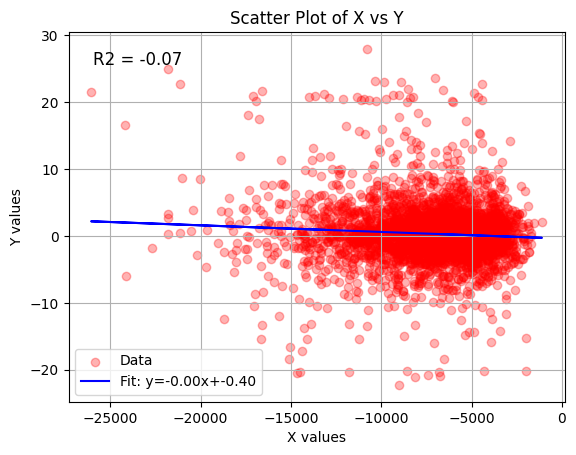

/var/folders/j9/n79dq8zs23qbyhwf5323s_lw0000gn/T/ipykernel_67300/3103165630.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()


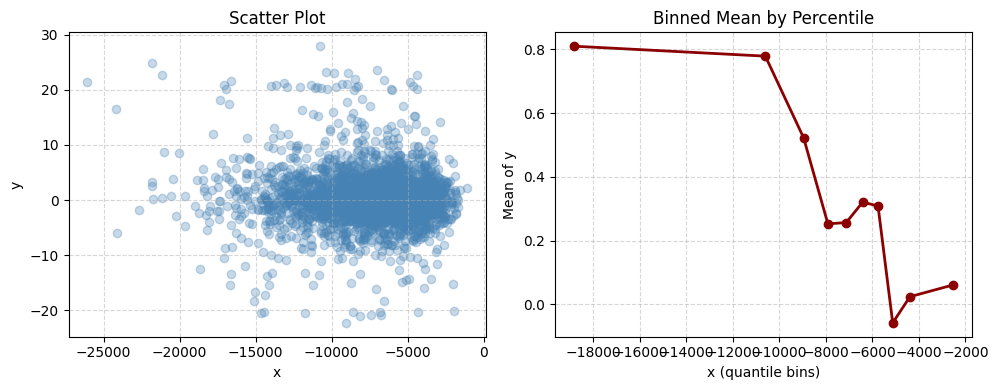

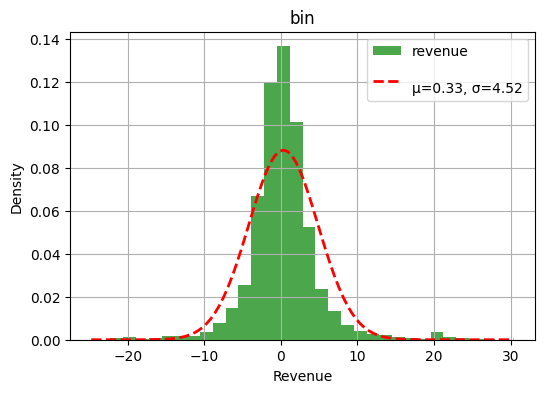

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# 假设 stats_1 和 revenues 已经定义为一维数组或列表
x = np.array(stats)
y = np.array(revenues)

# 线性回归
slope, intercept = np.polyfit(x, y, 1)
y_pred = slope * x + intercept

# 相关系数
r = np.corrcoef(x, y)[0, 1]

plt.scatter(x, y, color='red', alpha=0.3, label='Data')
plt.plot(x, y_pred, color='blue', label=f'Fit: y={slope:.2f}x+{intercept:.2f}')
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Scatter Plot of X vs Y")
plt.grid(True)
plt.legend()

# 在图上显示相关系数
plt.text(0.05, 0.95, f'R2 = {r:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')

plt.show()
plt.close()

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

x = np.array(stats)
y = np.array(revenues)

# === 按百分比分箱 ===
n_bins = 10
quantiles = np.linspace(0, 1, n_bins + 1)
bins = np.quantile(x, quantiles)  # 按x的分位数分箱

# 为避免重复的边界（在x有重复值时）
bins = np.unique(bins)

bin_labels = pd.cut(x, bins=bins, include_lowest=True)
bin_means = pd.DataFrame({'x_bin': bin_labels, 'y': y}).groupby('x_bin')['y'].mean()
bin_centers = [(interval.left + interval.right) / 2 for interval in bin_means.index]

# === 两个子图（不共享 y） ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# 左边：散点图
ax1.scatter(x, y, alpha=0.3, color='steelblue')
ax1.set_xlabel("x")
ax1.set_ylabel("y")
ax1.set_title("Scatter Plot")
ax1.grid(True, linestyle='--', alpha=0.5)

# 右边：分箱均值图
ax2.plot(bin_centers, bin_means.values, color='darkred', marker='o', lw=2)
ax2.set_xlabel("x (quantile bins)")
ax2.set_ylabel("Mean of y")
ax2.set_title("Binned Mean by Percentile")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
plt.close()


import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# 假设 y 是收益率数组
mu, std = norm.fit(y)  # 拟合正态分布，得到均值和标准差

plt.figure(figsize=(6, 4))
count, bins, ignored = plt.hist(y, bins=30, color='green', alpha=0.7, density=True, label='revenue')

# 拟合的正态分布曲线
xmin, xmax = plt.xlim()
x_fit = np.linspace(xmin, xmax, 100)
p_fit = norm.pdf(x_fit, mu, std)
plt.plot(x_fit, p_fit, 'r--', linewidth=2, label=f'\nμ={mu:.2f}, σ={std:.2f}')

plt.xlabel("Revenue")
plt.ylabel("Density")
plt.title("bin")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
# revenues

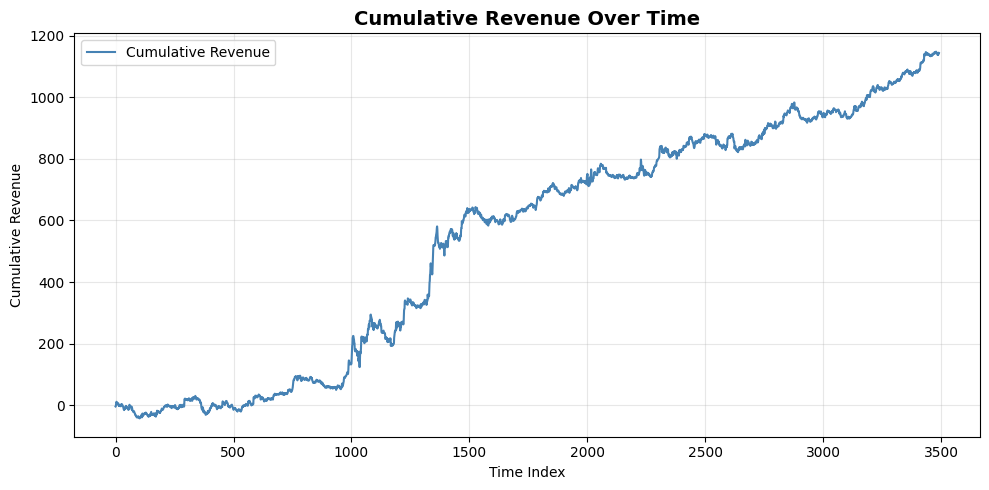

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 假设 revenue_series 是 pandas Series 或 numpy array
# 示例：
revenue_series = pd.Series(revenues)

# 1️⃣ 累积收益
cumulative_revenue = np.cumsum(revenue_series)

# 2️⃣ 绘图
plt.figure(figsize=(10, 5))
plt.plot(cumulative_revenue, label='Cumulative Revenue', color='steelblue', linewidth=1.5)
plt.title("Cumulative Revenue Over Time", fontsize=14, fontweight='bold')
plt.xlabel("Time Index")
plt.ylabel("Cumulative Revenue")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("cumulative_revenue.png", dpi=300)


In [ ]:
revenue_series.describe()

count    3491.000000
mean        0.327653
std         4.516360
min       -22.264642
25%        -1.795068
50%         0.053955
75%         2.104642
max        27.920658
dtype: float64